In [107]:
import pandas as pd
import vectorbt as vbt
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals
from ggTrader.Utils import *


In [108]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    # "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    # "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    # "TON",  # 20 Toncoin
    # "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    # "MNT",  # 23 Mantle
    # "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Walk Forward Optimization

In [109]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
# symbols = ["BTC", "ETH", "LTC"]
symbols = top_kraken[:]
interval = "4h"
n_trials = 50
# sampler = RandomSampler(seed=42)  # optional seed for reproducibility
sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.02,
                  'sar_maximum': 0.2,
                  'atr_multiplier': 3,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,  # atr multiplier for chandelier exit
                  'use_high': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)
close = data_df.xs('close', axis=1, level=1)
print(close.info())
print(close.columns)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-01-01 00:00:00+00:00 to 2025-09-30 00:00:00+00:00
Freq: 4h
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BTC     6019 non-null   float32
 1   ETH     6019 non-null   float32
 2   XRP     6019 non-null   float32
 3   SOL     6019 non-null   float32
 4   TRX     6019 non-null   float32
 5   DOGE    6019 non-null   float32
 6   ADA     6019 non-null   float32
 7   LINK    6019 non-null   float32
 8   BCH     6019 non-null   float32
 9   XLM     6019 non-null   float32
 10  SUI     5284 non-null   float32
 11  AVAX    6019 non-null   float32
 12  ZEC     6019 non-null   float32
 13  LTC     6019 non-null   float32
 14  XMR     6019 non-null   float32
 15  SHIB    6019 non-null   float32
 16  DOT     6019 non-null   float32
 17  UNI     6019 non-null   float32
dtypes: float32(18)
memory usage: 470.2 KB
None
Index(['BTC', 'ETH', 'XRP', 'SOL', 'TRX', 'DOGE'

Computed test_size=1205, max_train_size=2403


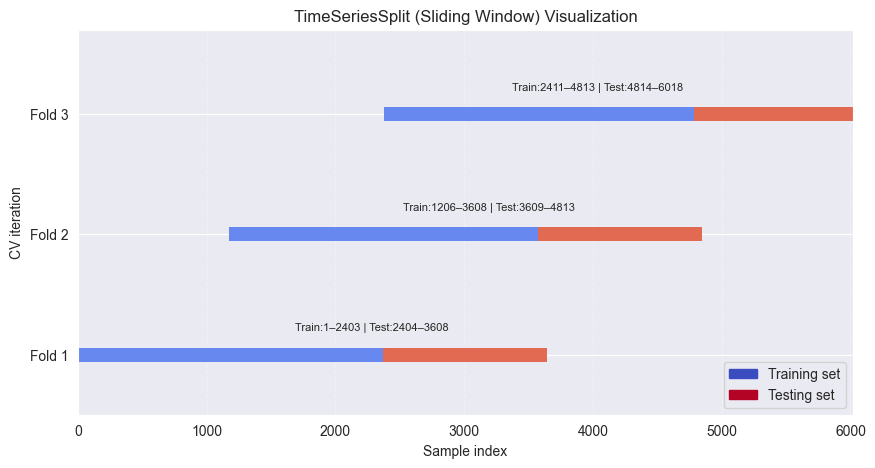

   Fold               Start                 End          Start Test  \
0     1 2023-01-01 04:00:00 2024-02-05 12:00:00 2024-02-05 16:00:00   
1     2 2023-07-21 00:00:00 2024-08-24 08:00:00 2024-08-24 12:00:00   
2     3 2024-02-06 20:00:00 2025-03-13 04:00:00 2025-03-13 08:00:00   

             End Test      Train Period       Test Period  
0 2024-08-24 08:00:00 400 days 08:00:00 200 days 16:00:00  
1 2025-03-13 04:00:00 400 days 08:00:00 200 days 16:00:00  
2 2025-09-30 00:00:00 400 days 08:00:00 200 days 16:00:00  


In [110]:
# Train split
n_splits = 3
test_ratio = 0.334
tscv, test_size, max_train_size = make_end_anchored_tscv(n_samples=len(data_df), n_splits=n_splits,
                                                         test_ratio=test_ratio)
print(f"Computed test_size={test_size}, max_train_size={max_train_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_indices(tscv, data_df.index, ax, n_splits)
plt.show()
# 4. Print fold ranges
rows = []
for i, (tr, tt) in enumerate(tscv.split(data_df.index), 1):
    start_train = data_df.index[tr[0]].tz_convert(None)
    end_train = data_df.index[tr[-1]].tz_convert(None)
    start_test = data_df.index[tt[0]].tz_convert(None)
    end_test = data_df.index[tt[-1]].tz_convert(None)

    rows.append({
        'Fold': i,
        'Start': start_train,
        'End': end_train,
        'Start Test': start_test,
        'End Test': end_test,
        'Train Period': end_train - start_train,
        'Test Period': end_test - start_test
    })

dur_df = pd.DataFrame(rows)
print(dur_df)


In [111]:
# ========= 2. Signal Data Comparison =========

def entry_signals(close,
                  high,
                  low,
                  adx_length: int = 14,
                  adx_threshold: int = 25,
                  sar_acceleration: float = 0.02,
                  sar_maximum: float = 0.2):
    sar_pandas_ta = vbt.pandas_ta('psar').run(high,
                                              low,
                                              close=close,
                                              acceleration=sar_acceleration,
                                              maximum=sar_maximum)
    sar_buy = sar_pandas_ta.psarl_below(close)

    adx_pandas_ta = vbt.pandas_ta('adx').run(high, low, close, length=adx_length)
    dmp_cross = adx_pandas_ta.dmp_above(adx_pandas_ta.dmn)
    adx_threshold_cross = adx_pandas_ta.adx_above(adx_threshold)
    adx_buy = dmp_cross & adx_threshold_cross

    return sar_buy & adx_buy


def stop_loss(entries, close, high, low, atr_length: int = 14, atr_multiplier: float = 3.0, use_high: bool = False):
    atr = vbt.pandas_ta('atr').run(high, low, close, length=atr_length)
    atrr = atr.atrr

    if use_high:
        entry_price = high.where(entries).ffill()
    else:
        entry_price = close.where(entries).ffill()

    # 3) 3x ATR stop distance as a fraction of entry
    #    (this is already positive: 3 * atr below entry)
    sl_stop = (atr_multiplier * atrr.values) / entry_price

    # Optional: if entry_price is NaN (no trade yet), keep NaN
    sl_stop = sl_stop.where(entry_price.notna())

    return sl_stop


def calc_signals(close: pd.DataFrame,
                 high: pd.DataFrame,
                 low: pd.DataFrame,
                 adx_length: int = 14,
                 adx_threshold: int = 25,
                 sar_acceleration: float = 0.02,
                 sar_maximum: float = 0.2,
                 atr_multiplier: float = 3.0,
                 atr_length: int = 14,
                 use_high: bool = False, ):
    entries = entry_signals(close, high, low, adx_length=adx_length, adx_threshold=adx_threshold,
                            sar_acceleration=sar_acceleration, sar_maximum=sar_maximum)
    exits = pd.DataFrame(False, index=entries.index, columns=entries.columns)
    sl_stop = stop_loss(entries, close, high, low, atr_multiplier=atr_multiplier, atr_length=atr_length,
                        use_high=use_high)
    return entries, exits, sl_stop





In [112]:
def reassign_columns_value(stats_df: pd.DataFrame, trial_num: int, level: int = 0):
    new_level_0 = stats_df.columns.levels[level].to_numpy().copy()
    new_level_0[:] = trial_num
    new_levels = [pd.Index(new_level_0), stats_df.columns.levels[1]]
    new_columns = stats_df.columns.set_levels(new_levels)

    # Assign back
    stats_df.columns = new_columns

    stats_df.columns = stats_df.columns.set_names(['id', 'symbol'])
    return stats_df


def assign_column_labels(stats_df: pd.DataFrame, labels: list):
    return stats_df.rename_axis(labels, axis=1)


def stats_df_to_wide(df: pd.DataFrame, trial_num: int):
    df = reassign_columns_value(df, trial_num, level=0)
    df = assign_column_labels(df, labels=['id', 'symbol'])
    df = df.T.reset_index()
    return convert_cols_to_numeric(df)


def convert_cols_to_numeric(df: pd.DataFrame):
    df['Start'] = pd.to_datetime(df['Start'], errors='coerce')
    df['End'] = pd.to_datetime(df['End'], errors='coerce')
    df['Period'] = pd.to_timedelta(df['Period'], errors='coerce')
    duration_str = 'Duration'
    for col in df.columns:
        # Skip columns we already converted to datetime/timedelta
        if col in ['Start', 'End', 'Period']:
            continue

        # Skip columns that are already numeric
        if pd.api.types.is_numeric_dtype(df[col]):
            continue
        if duration_str in col:
            df[col] = pd.to_timedelta(df[col], errors='coerce')
            continue
        # Try converting to numeric, catching exceptions
        try:
            df[col] = pd.to_numeric(df[col], errors='raise')

        except (ValueError, TypeError):
            # If conversion fails, leave the column as-is
            pass
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

Optuna setup

In [113]:
best_params_list = []
value_list = []
fold_test_performance_list = []
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

for i, (tr, tt) in enumerate(tscv.split(data_df.index), 1):
    df_train = data_df.iloc[tr]
    df_test = data_df.iloc[tt]

    print(f"{symbols} Fold {i}/{n_splits}:")
    close = df_train.xs('close', axis=1, level=1)
    high = df_train.xs('high', axis=1, level=1)
    low = df_train.xs('low', axis=1, level=1)
    open = df_train.xs('open', axis=1, level=1)


    def objective(trial: optuna.Trial):
        # Entry
        params['adx_threshold'] = trial.suggest_int("adx_threshold", 20, 46, step=2)  #
        params['adx_length'] = trial.suggest_int("adx_length", 10, 26, step=2)
        # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
        # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

        # Exit
        params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 2, 6, step=0.5)
        params['atr_length'] = trial.suggest_int("atr_length", 14, 40, step=2)
        # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

        entries, exits, sl_stop = calc_signals(close, high, low, **params)

        pf_train = vbt.Portfolio.from_signals(close,
                                              entries=entries,
                                              exits=exits,
                                              size=1,
                                              size_type='percent',
                                              direction='longonly',
                                              sl_stop=sl_stop,
                                              sl_trail=True,
                                              freq=interval,
                                              fees=transaction_fee,
                                              init_cash=start_equity,
                                              )
        stats_df = pd.DataFrame({col: pf_train[col].stats() for col in pf_train.wrapper.columns})
        sharpe = stats_df.loc["Sharpe Ratio"].mean()

        if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
            raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
        wide = stats_df_to_wide(stats_df, trial.number)
        params_df = pd.DataFrame(params, index=wide.index)
        trial_summary = pd.concat([wide, params_df], axis=1)
        trials_summary_list.append(trial_summary)

        return sharpe


    trials_summary_list = []

    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

    best_params = study.best_params
    best_params_list.append(best_params)

    #-------- backtest best parameters on test set-------
    for param in best_params.keys():
        params[param] = best_params[param]

    close = df_test.xs('close', axis=1, level=1)
    high = df_test.xs('high', axis=1, level=1)
    low = df_test.xs('low', axis=1, level=1)
    open = df_test.xs('open', axis=1, level=1)
    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe_series = stats_df.loc["Sharpe Ratio"]
    sharpe_mean = sharpe_series.replace([np.inf, -np.inf], np.nan).mean(skipna=True)
    sharpe = sharpe_mean
    value_list.append(sharpe)

    fold_test_performance_wide = stats_df_to_wide(stats_df, i)
    fold_test_performance_list.append(fold_test_performance_wide)

fold_test_performance_df = pd.concat(fold_test_performance_list, axis=0).reset_index(drop=True)
print(f"...Optimization Complete")

[I 2025-11-09 17:17:20,734] A new study created in memory with name: no-name-a1527c04-d9b4-4f99-83af-8f7cd049f05c


['BTC', 'ETH', 'XRP', 'SOL', 'TRX', 'DOGE', 'ADA', 'LINK', 'BCH', 'XLM', 'SUI', 'AVAX', 'ZEC', 'LTC', 'XMR', 'SHIB', 'DOT', 'UNI'] Fold 1/3:


[I 2025-11-09 17:17:22,434] Trial 0 finished with value: 0.33739445484813996 and parameters: {'adx_threshold': 30, 'adx_length': 26, 'atr_multiplier': 5.0, 'atr_length': 30}. Best is trial 0 with value: 0.33739445484813996.
[I 2025-11-09 17:17:24,172] Trial 1 finished with value: 0.7554822814045273 and parameters: {'adx_threshold': 24, 'adx_length': 12, 'atr_multiplier': 2.0, 'atr_length': 38}. Best is trial 1 with value: 0.7554822814045273.
[I 2025-11-09 17:17:25,584] Trial 2 finished with value: 0.2427648372915104 and parameters: {'adx_threshold': 36, 'adx_length': 22, 'atr_multiplier': 2.0, 'atr_length': 40}. Best is trial 1 with value: 0.7554822814045273.
[I 2025-11-09 17:17:27,333] Trial 3 finished with value: 0.10929601812438389 and parameters: {'adx_threshold': 42, 'adx_length': 12, 'atr_multiplier': 2.5, 'atr_length': 18}. Best is trial 1 with value: 0.7554822814045273.
[I 2025-11-09 17:17:28,709] Trial 4 finished with value: 0.1700067098144472 and parameters: {'adx_threshold':

['BTC', 'ETH', 'XRP', 'SOL', 'TRX', 'DOGE', 'ADA', 'LINK', 'BCH', 'XLM', 'SUI', 'AVAX', 'ZEC', 'LTC', 'XMR', 'SHIB', 'DOT', 'UNI'] Fold 2/3:


[I 2025-11-09 17:18:45,911] Trial 0 finished with value: 0.11361639515561747 and parameters: {'adx_threshold': 22, 'adx_length': 18, 'atr_multiplier': 2.0, 'atr_length': 38}. Best is trial 0 with value: 0.11361639515561747.
[I 2025-11-09 17:18:47,424] Trial 1 finished with value: -0.24039416741262723 and parameters: {'adx_threshold': 26, 'adx_length': 20, 'atr_multiplier': 3.0, 'atr_length': 28}. Best is trial 0 with value: 0.11361639515561747.
[I 2025-11-09 17:18:48,904] Trial 2 finished with value: 0.4634215985615293 and parameters: {'adx_threshold': 34, 'adx_length': 12, 'atr_multiplier': 6.0, 'atr_length': 34}. Best is trial 2 with value: 0.4634215985615293.
[I 2025-11-09 17:18:50,749] Trial 3 pruned. Invalid objective (NaN/Inf).
[I 2025-11-09 17:18:52,254] Trial 4 finished with value: 0.03726157237036045 and parameters: {'adx_threshold': 22, 'adx_length': 12, 'atr_multiplier': 2.0, 'atr_length': 22}. Best is trial 2 with value: 0.4634215985615293.
[I 2025-11-09 17:18:54,092] Trial

['BTC', 'ETH', 'XRP', 'SOL', 'TRX', 'DOGE', 'ADA', 'LINK', 'BCH', 'XLM', 'SUI', 'AVAX', 'ZEC', 'LTC', 'XMR', 'SHIB', 'DOT', 'UNI'] Fold 3/3:


[I 2025-11-09 17:20:09,593] Trial 0 finished with value: 0.14606275760891962 and parameters: {'adx_threshold': 44, 'adx_length': 20, 'atr_multiplier': 3.0, 'atr_length': 14}. Best is trial 0 with value: 0.14606275760891962.
[I 2025-11-09 17:20:11,104] Trial 1 finished with value: 0.6103599497820533 and parameters: {'adx_threshold': 28, 'adx_length': 14, 'atr_multiplier': 5.0, 'atr_length': 30}. Best is trial 1 with value: 0.6103599497820533.
[I 2025-11-09 17:20:12,972] Trial 2 finished with value: 0.2478104212490385 and parameters: {'adx_threshold': 44, 'adx_length': 18, 'atr_multiplier': 2.5, 'atr_length': 32}. Best is trial 1 with value: 0.6103599497820533.
[I 2025-11-09 17:20:14,468] Trial 3 finished with value: 0.7208538464470229 and parameters: {'adx_threshold': 40, 'adx_length': 20, 'atr_multiplier': 5.0, 'atr_length': 26}. Best is trial 3 with value: 0.7208538464470229.
[I 2025-11-09 17:20:16,302] Trial 4 finished with value: 0.24935165604643325 and parameters: {'adx_threshold':

...Optimization Complete


C:\Users\gkuep\AppData\Local\Temp\ipykernel_24276\2166992725.py:89: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [114]:
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]',
               'Benchmark Return [%]', 'Total Trades']

print("\nWalk Forward Optimization Results:")
rows = [{**p, "score": float(s), "fold": i + 1} for i, (p, s) in enumerate(zip(best_params_list, value_list))]
df_result = pd.DataFrame(rows).set_index("fold")
print(tabulate(df_result, headers="keys", tablefmt="github"))
result_stats = df_result.describe()

print("\nWalk Forward Optimization Stats:")
print(tabulate(result_stats, headers="keys", tablefmt="github"))

print("\nFold Test Performance:")
cols = ['id', 'symbol'] + performance
print(fold_test_performance_df[cols].to_string())
print(fold_test_performance_df[cols].describe().to_string())
print(fold_test_performance_df.columns)


Walk Forward Optimization Results:
|   fold |   adx_threshold |   adx_length |   atr_multiplier |   atr_length |    score |
|--------|-----------------|--------------|------------------|--------------|----------|
|      1 |              28 |           10 |              5.5 |           40 | 0.630508 |
|      2 |              26 |           10 |              6   |           38 | 0.477928 |
|      3 |              42 |           14 |              4   |           30 | 0.805066 |

Walk Forward Optimization Stats:
|       |   adx_threshold |   adx_length |   atr_multiplier |   atr_length |    score |
|-------|-----------------|--------------|------------------|--------------|----------|
| count |          3      |       3      |          3       |       3      | 3        |
| mean  |         32      |      11.3333 |          5.16667 |      36      | 0.637834 |
| std   |          8.7178 |       2.3094 |          1.04083 |       5.2915 | 0.163692 |
| min   |         26      |      10      |   

Run final backtest with average parameters

In [115]:
# reset params
params = params_default.copy()
for param in best_params.keys():
    params[param] = best_params[param]

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)

entries, exits, sl_stop = calc_signals(close, high, low, **params)

pf = vbt.Portfolio.from_signals(close,
                                entries=entries,
                                exits=exits,
                                size=1,
                                size_type='percent',
                                direction='longonly',
                                sl_stop=sl_stop,
                                sl_trail=True,
                                freq=interval,
                                fees=transaction_fee,
                                init_cash=start_equity,
                                )
print(list(stats_df.index))
print(best_params)

['Start', 'End', 'Period', 'Start Value', 'End Value', 'Total Return [%]', 'Benchmark Return [%]', 'Max Gross Exposure [%]', 'Total Fees Paid', 'Max Drawdown [%]', 'Max Drawdown Duration', 'Total Trades', 'Total Closed Trades', 'Total Open Trades', 'Open Trade PnL', 'Win Rate [%]', 'Best Trade [%]', 'Worst Trade [%]', 'Avg Winning Trade [%]', 'Avg Losing Trade [%]', 'Avg Winning Trade Duration', 'Avg Losing Trade Duration', 'Profit Factor', 'Expectancy', 'Sharpe Ratio', 'Calmar Ratio', 'Omega Ratio', 'Sortino Ratio']
{'adx_threshold': 42, 'adx_length': 14, 'atr_multiplier': 4.0, 'atr_length': 30}


In [116]:
stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
final_test_performance_wide = stats_df_to_wide(stats_df, 0)
print(final_test_performance_wide[cols].sort_values('Sharpe Ratio', ascending=False).to_string())

    id symbol  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Profit Factor  Total Return [%]  Benchmark Return [%]  Total Trades
0    0    BTC      1.399410       2.179316      1.493691       2.954018        132.548232            592.708492            19
2    0    XRP      1.350404       2.189790      2.261263       5.477663        257.938103            750.135899            15
3    0    SOL      1.195047       1.929291      1.591852       2.613912        229.659020           2010.510445            21
8    0    BCH      1.148254       1.806260      1.329891            NaN        447.199978            482.037687             1
15   0   SHIB      1.140930       1.990859      1.438976       4.344974        202.854398             46.592319            12
9    0    XLM      1.073600       1.994185      1.189312       2.277908        193.908949            421.421003            16
1    0    ETH      1.026044       1.478081      0.845915            NaN        234.422464            251.895094       

In [117]:
n = 0
pf[pf.wrapper.columns[n]].plot(width=1200, height=1900, title=f"{symbols[n]}").show()

In [118]:
# # Python
# from pathlib import Path
# import pandas as pd
#
# def load_or_create_csv(path, columns=None):
#     p = Path(path)
#     if p.exists():
#         return pd.read_csv(p,index_col=0)
#     # create empty DataFrame with optional columns
#     return pd.DataFrame(columns=columns or [])
#
# filename = "optimization_results.csv"
# df_stats_csv = load_or_create_csv(filename)
# print(df_stats_csv)
# df_stats_csv  = pd.concat([df_stats_csv, df_stats], ignore_index=False)
# print(df_stats_csv)
# df_stats_csv.to_csv(filename)

Test on latest result for the last 3 months

In [119]:
kd = KrakenData()

df_latest = kd.fetch_ohlcv_df(kd.kraken, symbols[0], timeframe='4h', limit=700)

s = Signals(**params)

signals = s.calc_signals(df_latest.copy())
close = signals['close']
entries = signals['entry_signal']
exits = signals['exit_signal']
# Build target allocation:
# 1.0 = 100% of portfolio in asset
# 0.0 = 100% in cash
size = pd.Series(np.nan, index=close.index)
size[entries] = 1.0  # on buy signal: go all-in
size[exits] = 0.0  # on sell signal: go flat

pf = vbt.Portfolio.from_orders(
    close=close,
    size=size,
    size_type='targetpercent',  # interpret `size` as target weight
    direction='longonly',
    init_cash=start_equity,  # starting cash
    fees=transaction_fee,  # 0.1% fee (optional)
    slippage=0.0005,  # optional
)

stats = pf.stats()
print(stats)

TypeError: Signals.__init__() got an unexpected keyword argument 'use_high'

In [17]:
pf.plot(width=1600, height=1500).show()